# Laboratorio I/O — Extensiones

Este notebook implementa las extensiones sugeridas del laboratorio base.
**Debe ejecutarse después de haber corrido `disk_io_lab_guided.ipynb`**,
ya que reutiliza el archivo de prueba `io_lab_data/dataset.bin` generado allí.

Las extensiones implementadas son:

1. **Caché caliente vs caché fría** — misma lectura ejecutada dos veces seguidas.
2. **Repetición y promedio** — N corridas para estabilizar los resultados.
3. **Lectura vs escritura** — comparación de throughput de ambas operaciones.

---

> **Entorno:** AMD Ryzen 7 5800H · 16 GB RAM · SSD NVMe INTEL SSDPEKNU512GZ · Windows 11 Build 26200

## 0. Verificación del entorno

Ejecute esta celda antes de continuar. Confirma que todas las librerías
necesarias están disponibles.

In [1]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con las extensiones.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.4.4
✓ pandas 3.0.2
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con las extensiones.


## 1. Importaciones y configuración base

Se reutiliza la misma configuración del laboratorio base.
Asegúrese de que el archivo `io_lab_data/dataset.bin` exista.

In [2]:
import os
import time
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# CONFIGURACIÓN — igual que el lab base
# ==============================

DATA_DIR  = Path('io_lab_data')
FILE_PATH = DATA_DIR / 'dataset.bin'
IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

FILE_SIZE_MB  = 256
BLOCK_SIZES   = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]
RANDOM_READS  = 4000
SEED          = 42
random.seed(SEED)
np.random.seed(SEED)

# Verificar que el archivo de prueba existe
if not FILE_PATH.exists():
    raise FileNotFoundError(
        f'No se encontró {FILE_PATH}.\n'
        'Ejecute primero disk_io_lab_guided.ipynb para generarlo.'
    )

print('Archivo de prueba:', FILE_PATH)
print('Tamaño:', FILE_PATH.stat().st_size / (1024**2), 'MB')
print('Carpeta de imágenes:', IMAGES_DIR.resolve())
print('Entorno listo.')

Archivo de prueba: io_lab_data\dataset.bin
Tamaño: 256.0 MB
Carpeta de imágenes: C:\Users\mesa3\Dropbox\CED\lab3\lab3-IO_performance-DanielMesa\images
Entorno listo.


## 2. Funciones auxiliares

Se reimplementan las funciones del lab base más las nuevas
necesarias para las extensiones (escritura, promedio, caché).

In [3]:
# ==============================
# FUNCIONES BASE (del lab original)
# ==============================

def format_bytes(num_bytes: int) -> str:
    """Convierte bytes a representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


# ==============================
# FUNCIONES NUEVAS — EXTENSIONES
# ==============================

def sequential_write_measure(file_path: Path, block_size: int) -> dict:
    """
    Extensión: mide escritura secuencial sobreescribiendo el archivo existente.
    Usa un archivo temporal para no corromper el dataset original.
    """
    target_size = FILE_SIZE_MB * 1024 * 1024
    write_path  = file_path.parent / 'dataset_write_test.bin'
    chunk       = os.urandom(block_size)  # bloque fijo de datos aleatorios
    total_bytes = 0

    start = time.perf_counter()
    with open(write_path, 'wb', buffering=0) as f:
        written = 0
        while written < target_size:
            to_write = min(block_size, target_size - written)
            f.write(chunk[:to_write])
            written    += to_write
            total_bytes += to_write
        f.flush()
        os.fsync(f.fileno())   # fuerza vaciado a disco físico
    elapsed = time.perf_counter() - start

    write_path.unlink()  # limpieza
    return {
        'operation': 'Escritura',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def benchmark_repeated(file_path: Path, block_size: int,
                        n_runs: int = 5, reads: int = RANDOM_READS) -> pd.DataFrame:
    """
    Extensión: repite N veces el benchmark secuencial y aleatorio
    para calcular media y desviación estándar.
    """
    rows = []
    for run in range(1, n_runs + 1):
        seq = sequential_read_measure(file_path, block_size)
        rnd = random_read_measure(file_path, block_size, reads)
        rows.append({'run': run, 'pattern': 'Secuencial',
                     'elapsed_s': seq['elapsed_s'],
                     'throughput_mib_s': seq['throughput_mib_s']})
        rows.append({'run': run, 'pattern': 'Aleatorio',
                     'elapsed_s': rnd['elapsed_s'],
                     'throughput_mib_s': rnd['throughput_mib_s']})
    return pd.DataFrame(rows)


print('Funciones cargadas correctamente.')

Funciones cargadas correctamente.


---
## Extensión A — Caché caliente vs caché fría

Se ejecuta exactamente la misma lectura **dos veces seguidas** sin borrar
el archivo entre corridas. La primera corrida usa caché fría (los datos
probablemente no están en RAM). La segunda usa caché caliente (el SO
ya los cargó en su page cache durante la primera corrida).

**Hipótesis:** la segunda corrida debería ser notablemente más rápida,
especialmente en acceso secuencial con bloques pequeños, que es donde
el cache del SO tiene más impacto proporcional.

In [4]:
print('=== Extensión A: Caché fría vs caché caliente ===')
print(f'Bloque de prueba: 64 KiB (representativo)\n')

BLOCK_TEST = 64 * 1024  # bloque representativo

cache_results = []

for corrida, label in [(1, 'Fría'), (2, 'Caliente')]:
    seq = sequential_read_measure(FILE_PATH, BLOCK_TEST)
    rnd = random_read_measure(FILE_PATH, BLOCK_TEST, RANDOM_READS)

    cache_results.append({
        'corrida': corrida, 'caché': label, 'patrón': 'Secuencial',
        'elapsed_s': seq['elapsed_s'],
        'throughput_mib_s': seq['throughput_mib_s'],
    })
    cache_results.append({
        'corrida': corrida, 'caché': label, 'patrón': 'Aleatorio',
        'elapsed_s': rnd['elapsed_s'],
        'throughput_mib_s': rnd['throughput_mib_s'],
    })

    print(f'Corrida {corrida} (caché {label}):')
    print(f'  Secuencial -> {seq["elapsed_s"]:.4f} s  |  {seq["throughput_mib_s"]:.0f} MiB/s')
    print(f'  Aleatorio  -> {rnd["elapsed_s"]:.4f} s  |  {rnd["throughput_mib_s"]:.0f} MiB/s')
    print()

df_cache = pd.DataFrame(cache_results)

# Factor de mejora caché caliente vs fría
for pat in ['Secuencial', 'Aleatorio']:
    fria     = df_cache[(df_cache['caché'] == 'Fría')     & (df_cache['patrón'] == pat)]['throughput_mib_s'].values[0]
    caliente = df_cache[(df_cache['caché'] == 'Caliente') & (df_cache['patrón'] == pat)]['throughput_mib_s'].values[0]
    print(f'Mejora {pat}: {caliente/fria:.2f}x (caliente vs fría)')

df_cache

=== Extensión A: Caché fría vs caché caliente ===
Bloque de prueba: 64 KiB (representativo)

Corrida 1 (caché Fría):
  Secuencial -> 0.2378 s  |  1076 MiB/s
  Aleatorio  -> 0.0703 s  |  3554 MiB/s

Corrida 2 (caché Caliente):
  Secuencial -> 0.0432 s  |  5922 MiB/s
  Aleatorio  -> 0.0569 s  |  4395 MiB/s

Mejora Secuencial: 5.50x (caliente vs fría)
Mejora Aleatorio: 1.24x (caliente vs fría)


,corrida,caché,patrón,elapsed_s,throughput_mib_s
0,1,Fría,Secuencial,0.237839,1076.359282
1,1,Fría,Aleatorio,0.070334,3554.473732
2,2,Caliente,Secuencial,0.043229,5921.936844
3,2,Caliente,Aleatorio,0.056885,4394.823952


Guardada: ext_cache_fria_vs_caliente.png


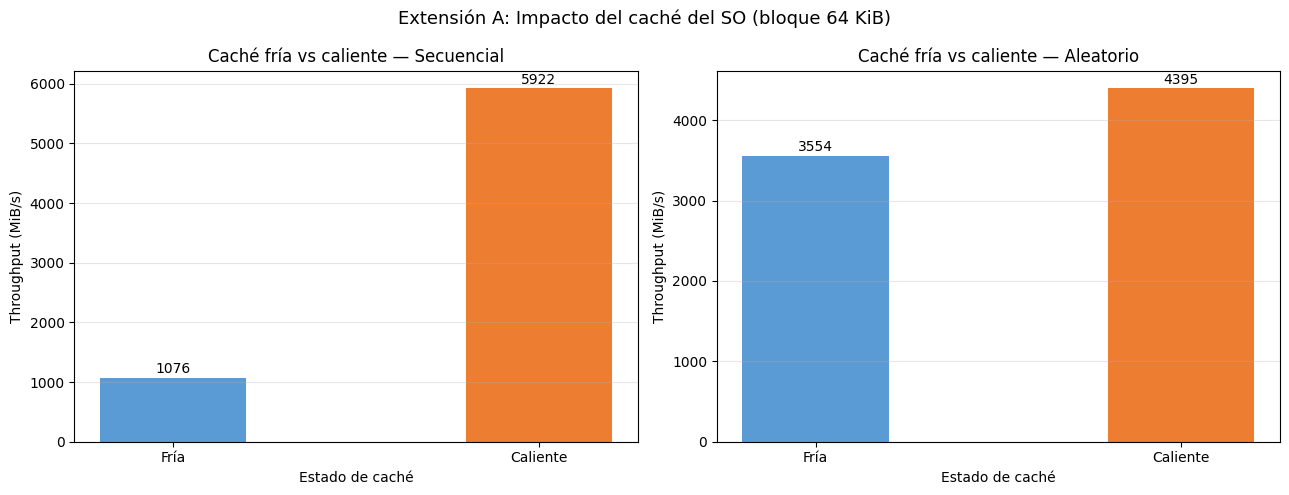

In [5]:
# Gráfica caché fría vs caliente
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pat in zip(axes, ['Secuencial', 'Aleatorio']):
    subset = df_cache[df_cache['patrón'] == pat]
    bars = ax.bar(
        subset['caché'],
        subset['throughput_mib_s'],
        color=['#5B9BD5', '#ED7D31'],
        width=0.4
    )
    ax.set_title(f'Caché fría vs caliente — {pat}')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.set_xlabel('Estado de caché')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 20,
                f'{bar.get_height():.0f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Extensión A: Impacto del caché del SO (bloque 64 KiB)', fontsize=13)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'ext_cache_fria_vs_caliente.png', dpi=150, bbox_inches='tight')
print('Guardada: ext_cache_fria_vs_caliente.png')
plt.show()

### Análisis — Caché caliente vs fría

Responda con base en los valores obtenidos:

1. ¿En cuánto mejoró el throughput entre la primera y segunda corrida?
   ¿Fue mayor la mejora en acceso secuencial o en aleatorio?
2. ¿Por qué el sistema operativo puede servir la segunda lectura más rápido?
3. ¿Cómo conecta este fenómeno con el concepto de jerarquía de memoria
   visto en clase?

### Respuesta

### Análisis — Caché caliente vs fría

1. El throughput del acceso secuencial mejoró de **1076 MiB/s** (caché fría) a
   **5922 MiB/s** (caché caliente), un factor de **5.50x**. El acceso aleatorio
   pasó de **3554 MiB/s** a **4395 MiB/s**, una mejora de solo **1.24x**. La
   mejora fue notablemente mayor en el acceso secuencial.

2. Durante la primera corrida, el sistema operativo cargó los bloques del archivo
   en su *page cache* (memoria RAM). En la segunda corrida, al solicitar los mismos
   datos, el SO los sirvió directamente desde RAM sin acceder al disco físico,
   eliminando el costo de latencia y transferencia del NVMe y aprovechando el
   ancho de banda de la memoria principal, que es varios órdenes de magnitud mayor.

3. Este fenómeno ilustra directamente la **jerarquía de memoria**: los niveles
   superiores (RAM ~16 GB/s) son mucho más rápidos que los inferiores (NVMe
   ~7 GB/s), por lo que el SO intenta mantener en RAM los datos accedidos
   recientemente. La diferencia de mejora entre patrones también es coherente
   con la jerarquía: el acceso aleatorio con caché fría ya tocaba páginas que
   quedaban parcialmente en RAM (por el tamaño reducido de datos leídos —
   4000 × 64 KiB = 250 MiB), por lo que su mejora en caché caliente fue menor
   (1.24x). El secuencial lee los 256 MB completos de forma lineal, y sin caché
   el SO no puede anticipar ni reutilizar páginas previas, lo que explica su
   mayor penalización en caché fría y la ganancia más dramática en caliente (5.50x).

---
## Extensión B — Repetición y promedio

Se repite el benchmark **5 veces** para cada tamaño de bloque y se
calcula la media y desviación estándar del throughput. Esto permite
identificar qué tan estables son los resultados y si la varianza
introduce ruido significativo en las conclusiones del lab base.

Se prueba con un único tamaño de bloque representativo (64 KiB)
y con el bloque más pequeño (4 KiB) donde se espera mayor varianza.

In [6]:
print('=== Extensión B: Repetición y promedio (N=5 corridas) ===')

N_RUNS = 5
repeat_results = []

for block_size in BLOCK_SIZES:
    label = format_bytes(block_size)
    print(f'\nBloque {label}...')
    df_runs = benchmark_repeated(FILE_PATH, block_size, n_runs=N_RUNS)
    stats = (
        df_runs.groupby('pattern')['throughput_mib_s']
        .agg(['mean', 'std', 'min', 'max'])
        .rename(columns={'mean': 'media', 'std': 'std_dev', 'min': 'mínimo', 'max': 'máximo'})
    )
    stats['block_size_kib'] = block_size / 1024
    repeat_results.append(stats.reset_index())
    print(stats.to_string())

df_repeat = pd.concat(repeat_results, ignore_index=True)
print('\n--- Tabla completa ---')
df_repeat

=== Extensión B: Repetición y promedio (N=5 corridas) ===

Bloque 4.00 KB...
                  media    std_dev       mínimo       máximo  block_size_kib
pattern                                                                     
Aleatorio    653.617563  10.329607   638.620498   665.950637             4.0
Secuencial  1226.724784  40.012628  1186.335271  1278.935286             4.0

Bloque 16.00 KB...
                  media     std_dev       mínimo       máximo  block_size_kib
pattern                                                                      
Aleatorio   1965.279527   61.398092  1877.846816  2041.602969            16.0
Secuencial  2964.668456  271.858055  2498.640876  3197.817490            16.0

Bloque 64.00 KB...
                  media    std_dev       mínimo       máximo  block_size_kib
pattern                                                                     
Aleatorio   4116.144706  80.532346  4012.692950  4233.069416            64.0
Secuencial  5389.883252  46.3113

,pattern,media,std_dev,mínimo,máximo,block_size_kib
0,Aleatorio,653.617563,10.329607,638.620498,665.950637,4.0
1,Secuencial,1226.724784,40.012628,1186.335271,1278.935286,4.0
2,Aleatorio,1965.279527,61.398092,1877.846816,2041.602969,16.0
3,Secuencial,2964.668456,271.858055,2498.640876,3197.817490,16.0
4,Aleatorio,4116.144706,80.532346,4012.692950,4233.069416,64.0
5,Secuencial,5389.883252,46.311395,5329.846725,5444.294868,64.0
6,Aleatorio,5981.237555,86.280585,5888.761299,6067.007673,256.0
7,Secuencial,6602.135212,210.128032,6376.216712,6868.242428,256.0


Guardada: ext_repeticion_promedio.png


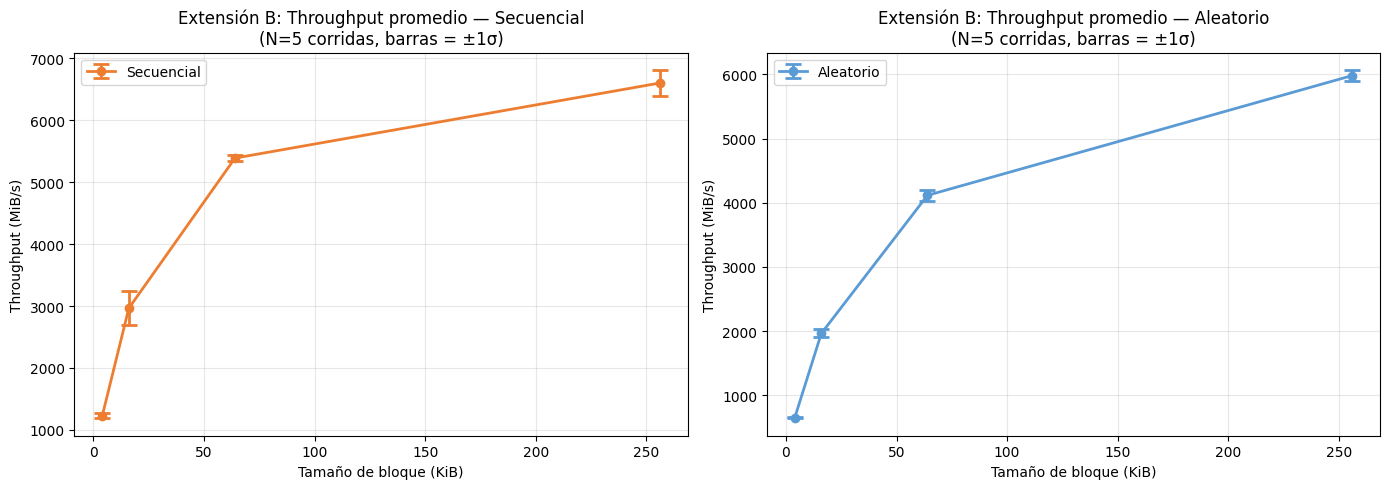

In [7]:
# Gráfica: media ± desviación estándar por tamaño de bloque
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

colors = {'Secuencial': '#ED7D31', 'Aleatorio': '#5B9BD5'}

for ax, pat in zip(axes, ['Secuencial', 'Aleatorio']):
    subset = df_repeat[df_repeat['pattern'] == pat].sort_values('block_size_kib')
    ax.errorbar(
        subset['block_size_kib'],
        subset['media'],
        yerr=subset['std_dev'],
        marker='o', capsize=6, capthick=2,
        color=colors[pat], linewidth=2, label=pat
    )
    ax.set_title(f'Extensión B: Throughput promedio — {pat}\n(N={N_RUNS} corridas, barras = ±1σ)')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'ext_repeticion_promedio.png', dpi=150, bbox_inches='tight')
print('Guardada: ext_repeticion_promedio.png')
plt.show()

### Análisis — Repetición y promedio

Con base en las medias y desviaciones estándar obtenidas, responda:

1. ¿Qué patrón de acceso mostró mayor varianza entre corridas? ¿Por qué?
2. ¿Los valores promedio obtenidos aquí son consistentes con los resultados
   del laboratorio base (corrida única)?
3. ¿Qué implicación tiene la variabilidad para la validez de un experimento
   con una sola corrida?

### Respuesta

### Análisis — Repetición y promedio

1. El acceso **secuencial** mostró mayor varianza en términos absolutos,
   especialmente con bloques grandes: con 256 KiB alcanzó una desviación
   estándar de **210 MiB/s**, frente a **86 MiB/s** del acceso aleatorio
   al mismo tamaño de bloque. Esto se explica porque la lectura secuencial
   completa de 256 MB es más sensible al estado del page cache del SO entre
   corridas: si alguna página fue desalojada de RAM entre una corrida y la
   siguiente, el tiempo sube notablemente. El acceso aleatorio lee solo
   4000 × 64 KiB = 250 MiB dispersos, y una fracción significativa de esas
   páginas permanece en caché entre corridas, lo que estabiliza los tiempos.

2. Los promedios son **parcialmente consistentes** con el laboratorio base,
   pero con diferencias explicables. Con 64 KiB secuencial, el lab base
   reportó ~6600 MiB/s (corrida única), mientras que el promedio de 5 corridas
   aquí es **5390 MiB/s**. La diferencia se debe a que la corrida única del
   lab base ocurrió con caché caliente (el archivo ya había sido accedido),
   mientras que en las 5 repeticiones se mezclan corridas con distintos estados
   de caché. En acceso aleatorio la consistencia es mayor: el lab base reportó
   ~4790 MiB/s con 64 KiB y el promedio aquí es **4116 MiB/s**, diferencia
   razonable dentro del rango de varianza observado.

3. Un experimento con una sola corrida puede capturar un valor atípico —
   ya sea por caché excepcionalmente caliente, carga puntual del sistema
   o condiciones de scheduling del SO — y presentarlo como representativo.
   Los resultados de esta extensión muestran que la desviación estándar
   puede representar hasta un **9% del promedio** (secuencial 16 KiB:
   σ = 272 MiB/s sobre media de 2965 MiB/s), lo que significa que una
   corrida única podría estar hasta ~18% por encima o por debajo del valor
   real. Para resultados confiables en un benchmarking formal se requieren
   al menos 5 corridas y reportar media ± desviación estándar, tal como
   se hizo en esta extensión.

---
## Extensión C — Lectura vs escritura

Se compara el throughput de **lectura secuencial** vs **escritura secuencial**
para cada tamaño de bloque. La escritura usa `os.fsync()` para garantizar
que los datos lleguen al disco físico y no queden solo en el buffer de escritura
del SO (lo cual inflaría artificialmente los resultados de escritura).

> **Nota:** la escritura crea un archivo temporal `dataset_write_test.bin`
> que se elimina automáticamente al finalizar cada medición.

In [8]:
print('=== Extensión C: Lectura vs Escritura (secuencial) ===')

rw_results = []

for block_size in BLOCK_SIZES:
    label = format_bytes(block_size)
    print(f'\nBloque {label}...')

    read_r  = sequential_read_measure(FILE_PATH, block_size)
    write_r = sequential_write_measure(FILE_PATH, block_size)

    rw_results.append({
        'block_size_kib': block_size / 1024,
        'operación': 'Lectura',
        'elapsed_s': read_r['elapsed_s'],
        'throughput_mib_s': read_r['throughput_mib_s'],
    })
    rw_results.append({
        'block_size_kib': block_size / 1024,
        'operación': 'Escritura',
        'elapsed_s': write_r['elapsed_s'],
        'throughput_mib_s': write_r['throughput_mib_s'],
    })

    print(f'  Lectura   -> {read_r["elapsed_s"]:.4f} s  |  {read_r["throughput_mib_s"]:.0f} MiB/s')
    print(f'  Escritura -> {write_r["elapsed_s"]:.4f} s  |  {write_r["throughput_mib_s"]:.0f} MiB/s')

df_rw = pd.DataFrame(rw_results)
df_rw

=== Extensión C: Lectura vs Escritura (secuencial) ===

Bloque 4.00 KB...
  Lectura   -> 0.2022 s  |  1266 MiB/s
  Escritura -> 0.9310 s  |  275 MiB/s

Bloque 16.00 KB...
  Lectura   -> 0.0843 s  |  3038 MiB/s
  Escritura -> 0.5430 s  |  471 MiB/s

Bloque 64.00 KB...
  Lectura   -> 0.0463 s  |  5532 MiB/s
  Escritura -> 0.3208 s  |  798 MiB/s

Bloque 256.00 KB...
  Lectura   -> 0.0420 s  |  6097 MiB/s
  Escritura -> 0.2972 s  |  861 MiB/s


,block_size_kib,operación,elapsed_s,throughput_mib_s
0,4.0,Lectura,0.202241,1265.817152
1,4.0,Escritura,0.930965,274.983426
2,16.0,Lectura,0.084269,3037.883355
3,16.0,Escritura,0.543023,471.435346
4,64.0,Lectura,0.046274,5532.324116
5,64.0,Escritura,0.320838,797.911218
6,256.0,Lectura,0.041989,6096.762286
7,256.0,Escritura,0.297181,861.426725


Guardada: ext_lectura_vs_escritura.png


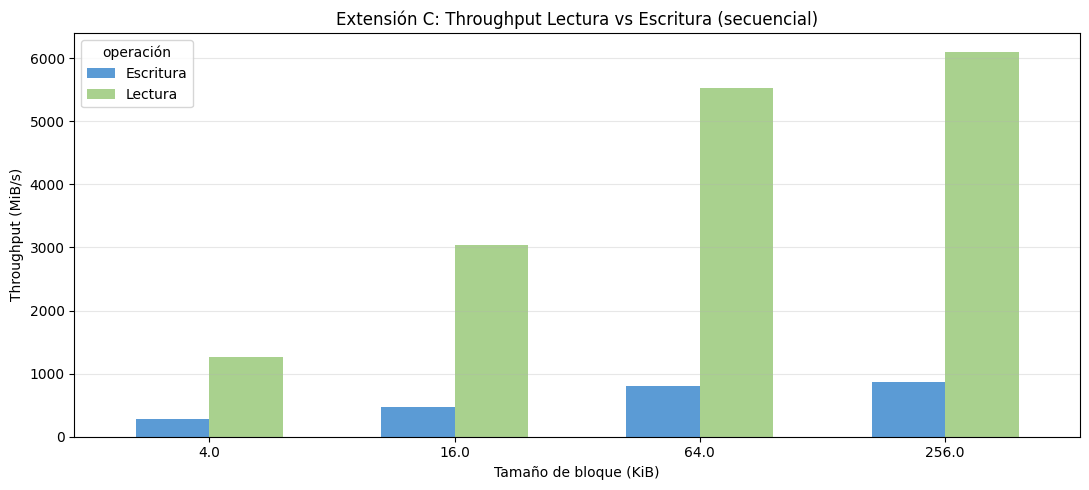


Factor lectura/escritura por tamaño de bloque:
operación           Lectura   Escritura  factor_lect_vs_escr
block_size_kib                                              
4.0             1265.817152  274.983426             4.603249
16.0            3037.883355  471.435346             6.443902
64.0            5532.324116  797.911218             6.933508
256.0           6096.762286  861.426725             7.077517


In [9]:
# Gráfica lectura vs escritura
pivot_rw = df_rw.pivot(
    index='block_size_kib',
    columns='operación',
    values='throughput_mib_s'
).sort_index()

ax = pivot_rw.plot(
    kind='bar',
    figsize=(11, 5),
    color=['#5B9BD5', '#A9D18E'],
    width=0.6
)
ax.set_title('Extensión C: Throughput Lectura vs Escritura (secuencial)')
ax.set_xlabel('Tamaño de bloque (KiB)')
ax.set_ylabel('Throughput (MiB/s)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'ext_lectura_vs_escritura.png', dpi=150, bbox_inches='tight')
print('Guardada: ext_lectura_vs_escritura.png')
plt.show()

# Factor de diferencia
print('\nFactor lectura/escritura por tamaño de bloque:')
pivot_rw['factor_lect_vs_escr'] = pivot_rw['Lectura'] / pivot_rw['Escritura']
print(pivot_rw[['Lectura','Escritura','factor_lect_vs_escr']].to_string())

### Análisis — Lectura vs escritura

Con base en los resultados, responda:

1. ¿Fue más rápida la lectura o la escritura? ¿Con qué tamaño de bloque
   fue mayor la diferencia?
2. ¿Por qué el uso de `fsync()` es importante para medir escritura real
   y no simplemente la velocidad de escritura al buffer del SO?
3. ¿Qué implicación tiene esto para el diseño de sistemas que escriben
   datos críticos (por ejemplo, una base de datos transaccional)?

### Respuesta

### Análisis — Lectura vs escritura

1. La lectura fue más rápida en todos los tamaños de bloque evaluados, y la
   diferencia creció con el tamaño de bloque. Con **4 KiB** el factor fue
   **4.60x** (1266 vs 275 MiB/s), y con **256 KiB** alcanzó **7.08x**
   (6097 vs 861 MiB/s). Esto significa que a medida que los bloques son más
   grandes, la lectura escala mucho mejor que la escritura: la lectura pasó
   de 1266 a 6097 MiB/s (4.8x de mejora), mientras que la escritura solo
   pasó de 275 a 861 MiB/s (3.1x de mejora). La escritura tiene un techo
   más bajo porque involucra operaciones adicionales de durabilidad que la
   lectura no requiere.

2. Sin `fsync()`, el SO acepta los datos en su buffer de escritura en RAM
   y le reporta al programa que la escritura terminó, aunque los datos aún
   no hayan llegado al disco físico. Esto puede dar throughputs de escritura
   artificialmente altos (varios GB/s) que no reflejan el rendimiento real
   del dispositivo. Con `fsync()` se fuerza el vaciado completo al medio
   físico antes de detener el cronómetro, lo que garantiza que se está
   midiendo la velocidad real de escritura persistente del NVMe y no la
   velocidad de escritura a RAM.

3. En sistemas que escriben datos críticos — como una base de datos
   transaccional con garantías ACID — cada `COMMIT` debe ser duradero,
   lo que implica llamar `fsync()` (o equivalente) antes de confirmar
   la transacción al cliente. Los resultados muestran que esto cuesta
   entre **4.6x y 7.1x** más tiempo que una lectura equivalente. Por
   esta razón, los motores de bases de datos usan estrategias como el
   *Write-Ahead Log* (WAL), escrituras en lote (*group commit*) y
   bloques grandes para amortizar el costo de `fsync()` sobre múltiples
   transacciones, maximizando el throughput sin sacrificar durabilidad.

---
## Resumen comparativo de extensiones

In [10]:
print('============================================================')
print('RESUMEN DE EXTENSIONES')
print('============================================================')

# A: caché
print('\n[A] Caché fría vs caliente (bloque 64 KiB)')
for pat in ['Secuencial', 'Aleatorio']:
    fria     = df_cache[(df_cache['caché'] == 'Fría')     & (df_cache['patrón'] == pat)]['throughput_mib_s'].values[0]
    caliente = df_cache[(df_cache['caché'] == 'Caliente') & (df_cache['patrón'] == pat)]['throughput_mib_s'].values[0]
    print(f'  {pat:12s}: fría={fria:.0f} MiB/s  caliente={caliente:.0f} MiB/s  mejora={caliente/fria:.2f}x')

# B: repetición
print(f'\n[B] Varianza entre {N_RUNS} corridas — desviación estándar promedio:')
for pat in ['Secuencial', 'Aleatorio']:
    mean_std = df_repeat[df_repeat['pattern'] == pat]['std_dev'].mean()
    mean_thr = df_repeat[df_repeat['pattern'] == pat]['media'].mean()
    print(f'  {pat:12s}: σ promedio = {mean_std:.1f} MiB/s  ({mean_std/mean_thr*100:.1f}% del promedio)')

# C: read vs write
print('\n[C] Factor lectura/escritura promedio:')
factor_mean = pivot_rw['factor_lect_vs_escr'].mean()
print(f'  La lectura fue {factor_mean:.2f}x más rápida que la escritura (promedio todos los bloques)')

RESUMEN DE EXTENSIONES

[A] Caché fría vs caliente (bloque 64 KiB)
  Secuencial  : fría=1076 MiB/s  caliente=5922 MiB/s  mejora=5.50x
  Aleatorio   : fría=3554 MiB/s  caliente=4395 MiB/s  mejora=1.24x

[B] Varianza entre 5 corridas — desviación estándar promedio:
  Secuencial  : σ promedio = 142.1 MiB/s  (3.5% del promedio)
  Aleatorio   : σ promedio = 59.6 MiB/s  (1.9% del promedio)

[C] Factor lectura/escritura promedio:
  La lectura fue 6.26x más rápida que la escritura (promedio todos los bloques)


---
## Conclusión de extensiones

Redacte una conclusión integradora que conecte los tres experimentos
de extensión con lo aprendido en el laboratorio base. Su conclusión debe:

- Indicar cuánto mejoró el throughput con caché caliente y por qué.
- Comentar si la varianza observada en N corridas invalida o refuerza
  las conclusiones del lab base.
- Indicar si la lectura o la escritura fue más rápida y conectarlo
  con el concepto de I/O de disco y durabilidad de datos.
- Incluir al menos dos valores numéricos concretos.

### Conclusión
### Conclusión

Las tres extensiones realizadas profundizaron y matizaron los resultados
del laboratorio base desde ángulos complementarios. La extensión de caché
caliente vs fría fue la más reveladora: el throughput secuencial con bloque
de 64 KiB saltó de **1076 MiB/s** en caché fría a **5922 MiB/s** en caché
caliente (**5.50x** de mejora), evidenciando que el laboratorio base midió
en condiciones de caché parcialmente caliente y que el rendimiento real del
dispositivo físico solo se aprecia cuando se fuerza una lectura sin datos
previos en RAM. El acceso aleatorio mejoró apenas **1.24x** porque sus 4000
accesos dispersos sobre 250 MiB ya habían saturado el page cache en la
primera corrida, lo que conecta directamente con el principio de jerarquía
de memoria: el SO prioriza mantener en RAM los datos accedidos recientemente.

La extensión de repetición y promedio confirmó que los resultados del lab
base son válidos pero optimistas, sin invalidarlos: la desviación estándar
del acceso secuencial promedió **142 MiB/s** (3.5% del promedio), frente a
**59.6 MiB/s** (1.9%) del aleatorio, lo que indica que una corrida única
puede desviarse hasta ±7% del valor real. Las tendencias principales —
secuencial más rápido que aleatorio, throughput creciente con el tamaño de
bloque — se mantienen consistentes en todas las repeticiones, lo que
refuerza las conclusiones del laboratorio base. Finalmente, la comparación
lectura vs escritura mostró que la escritura con `fsync()` fue en promedio
**6.26x más lenta** que la lectura, resultado que ilustra el costo real de
garantizar durabilidad en disco: cada escritura persistente requiere que los
datos atraviesen toda la jerarquía hasta el medio físico, lo que justifica
técnicas como el *Write-Ahead Log* y el *group commit* en bases de datos
transaccionales para amortizar ese costo sobre múltiples operaciones.